In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import os

data_folder = "./results/"
 
def get_csvs_recursive(dir_name):
    """
    recursively finds all .csv files below a specified directory and returns them as 
    a list of file paths. Usefull for combining results from multiple simulation runs.
    """
    dir_list = os.listdir(dir_name)
    cur_fnames = []
    
    for item_name in dir_list:
        # if file
        if ".csv" in item_name:
            cur_fnames += [dir_name+"/"+item_name]
        # if folder
        elif "." not in item_name:
            sub_fnames = get_csvs_recursive(dir_name+"/"+item_name)
            cur_fnames += sub_fnames
    return cur_fnames
            
    
data_fnames = get_csvs_recursive(data_folder)

# combine all files into a longform dataframe for plotting
sim_dfs= []
for filename in data_fnames:
    cur_df = pd.read_csv(filename)
    sim_dfs += [cur_df]
        
phrase_df = pd.concat(sim_dfs).reset_index(drop=True)

phrase_df.loc[phrase_df["char_lm_type"] == "dec19 (20 win diff)", "char_lm_type"] = "dec19"
phrase_df.loc[phrase_df["word_lm_type"] == "dec19 (20 win diff)", "word_lm_type"] = "dec19"

phrase_df.loc[phrase_df["char_lm_type"] == "dec19 (95 win diff)", "char_lm_type"] = "dec19"
phrase_df.loc[phrase_df["word_lm_type"] == "dec19 (95 win diff)", "word_lm_type"] = "dec19"

phrase_df.loc[phrase_df["win_diff"].isnull(), "win_diff"] = 99
phrase_df.loc[phrase_df["win_diff"] == 0.95, "win_diff"] = 95

phrase_df["lm_config"] = "char: "+phrase_df["char_lm_type"]+", word: "+phrase_df["word_lm_type"]

phrase_df["Phrase Set and Type"] = phrase_df["phrase_set"]+", "+phrase_df["Phrase Type"]

print("Unique Paramater Configurations Loaded:")
phrase_df.filter(items=["user_id", "char_lm_type", "word_lm_type", "phrase_set", "win_diff"]).drop_duplicates()

Unique Paramater Configurations Loaded:


,user_id,char_lm_type,word_lm_type,phrase_set,win_diff
0,A,dec19,off,LM likely,99.0
118,A,dec19 (no prior),off,LM likely,99.0
236,A,dec19,off,watch,99.0
358,A,dec19 (no prior),off,watch,99.0
480,A,dec19,dec19,watch,99.0
602,A,dec19 (no prior),dec19 (no prior),watch,99.0
724,A,dec19 (no prior),dec19 (no prior),LM likely,99.0
842,A,dec19,dec19,LM likely,99.0
960,A,dec19,dec19 (1 word),watch,99.0
1082,A,dec19 (no prior),dec19 (1 word no prior),watch,99.0


Text(0.5, 0.98, 'Word Prediction Off')

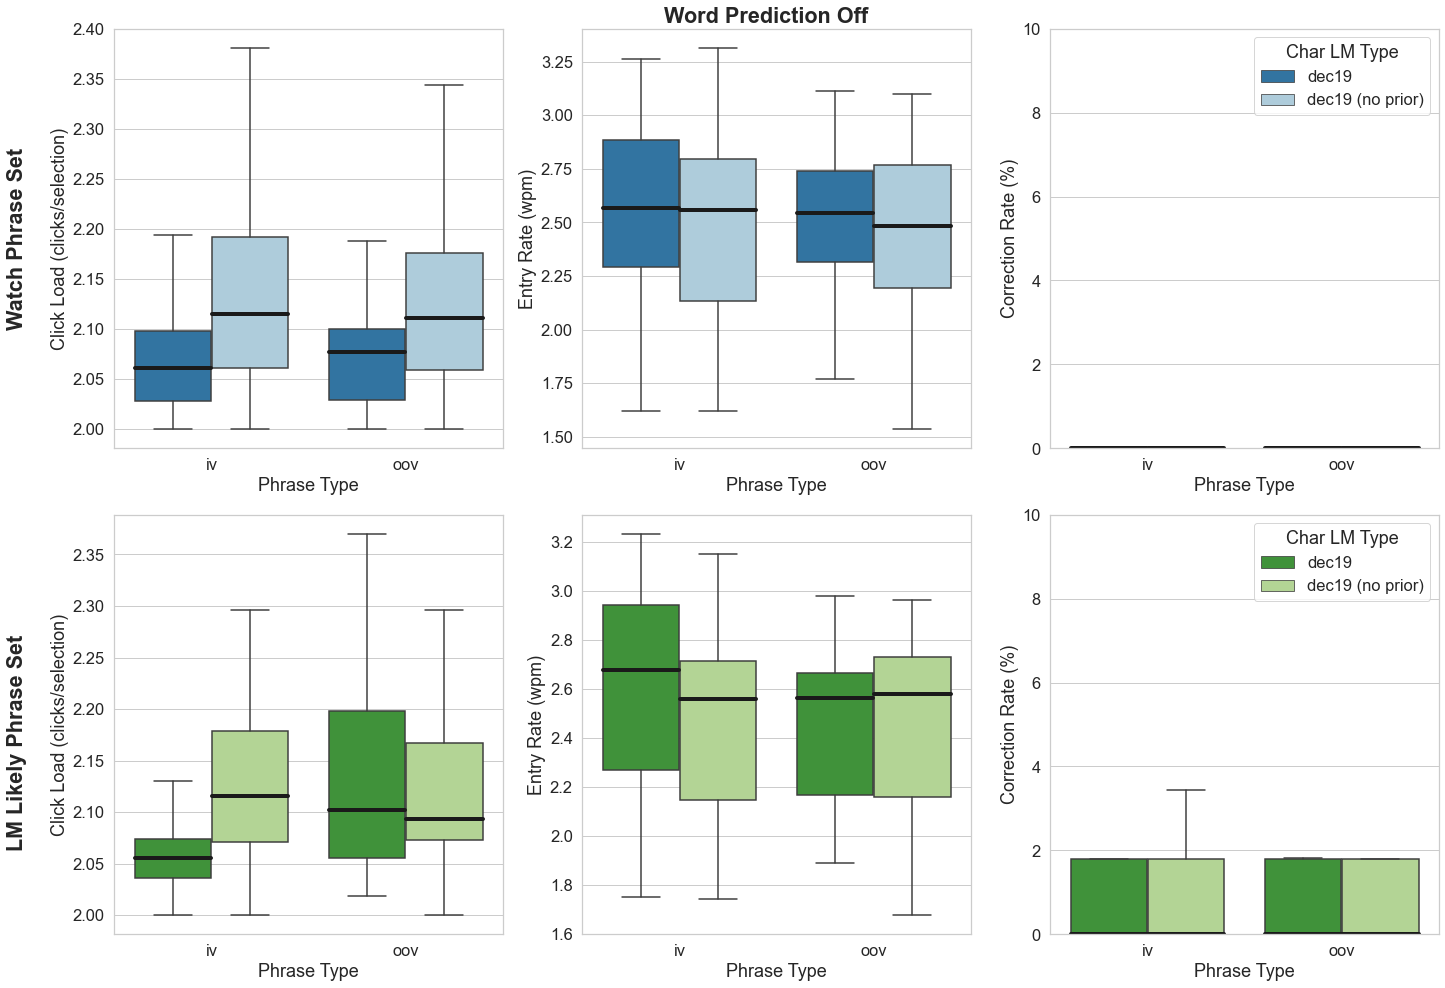

In [4]:
# setup and format a double figure for the plots
fig, axes = plt.subplots(2,3, figsize=(20, 14))
fig.tight_layout(pad=2)
sns.set_context("paper")
sns.set(font_scale=1.5)
sns.set_style("whitegrid")

# # plot the data as boxplots


for row_num, phrase_set in enumerate(["watch", "LM likely"]):
    plot_df = phrase_df.loc[phrase_df["word_lm_type"] == "off"]
    plot_df = plot_df.loc[plot_df["phrase_set"] == phrase_set]
    
    palette = sns.color_palette("Paired", 2*(row_num+1))[::-1]
    hue_order = ["dec19", "dec19 (no prior)"]

    dep_vars = ["Click Load (clicks/selection)", "Entry Rate (wpm)", "Correction Rate (%)"]

    for col_num, dep_var in enumerate(dep_vars):
        cur_ax = axes[row_num, col_num]
        
        box = sns.boxplot(data=plot_df, x="Phrase Type", y=dep_var, order=["iv", "oov"],
                    hue="char_lm_type", hue_order=hue_order, palette=palette,
                    showfliers=False, medianprops={"color": "k", "linewidth": 4}, ax=cur_ax)
        
        if dep_var == "Correction Rate (%)":
            cur_ymax = cur_ax.get_ylim()[1]
            cur_ax.set_ylim(0, max(10, cur_ymax))
            
        if col_num != 2:
            cur_ax.get_legend().remove()
        else:
            cur_ax.legend(loc=1)
            cur_ax.get_legend().set_title("Char LM Type")


fig.text(-0.02, 0.25, 'LM Likely Phrase Set', ha='center', va='center', rotation='vertical', fontsize="large", fontweight="bold")
fig.text(-0.02, 0.75, 'Watch Phrase Set', ha='center', va='center', rotation='vertical', fontsize="large", fontweight="bold")


fig.suptitle("Word Prediction Off", fontsize="large", fontweight="bold")


Text(0.5, 0.98, 'Word Prediction On')

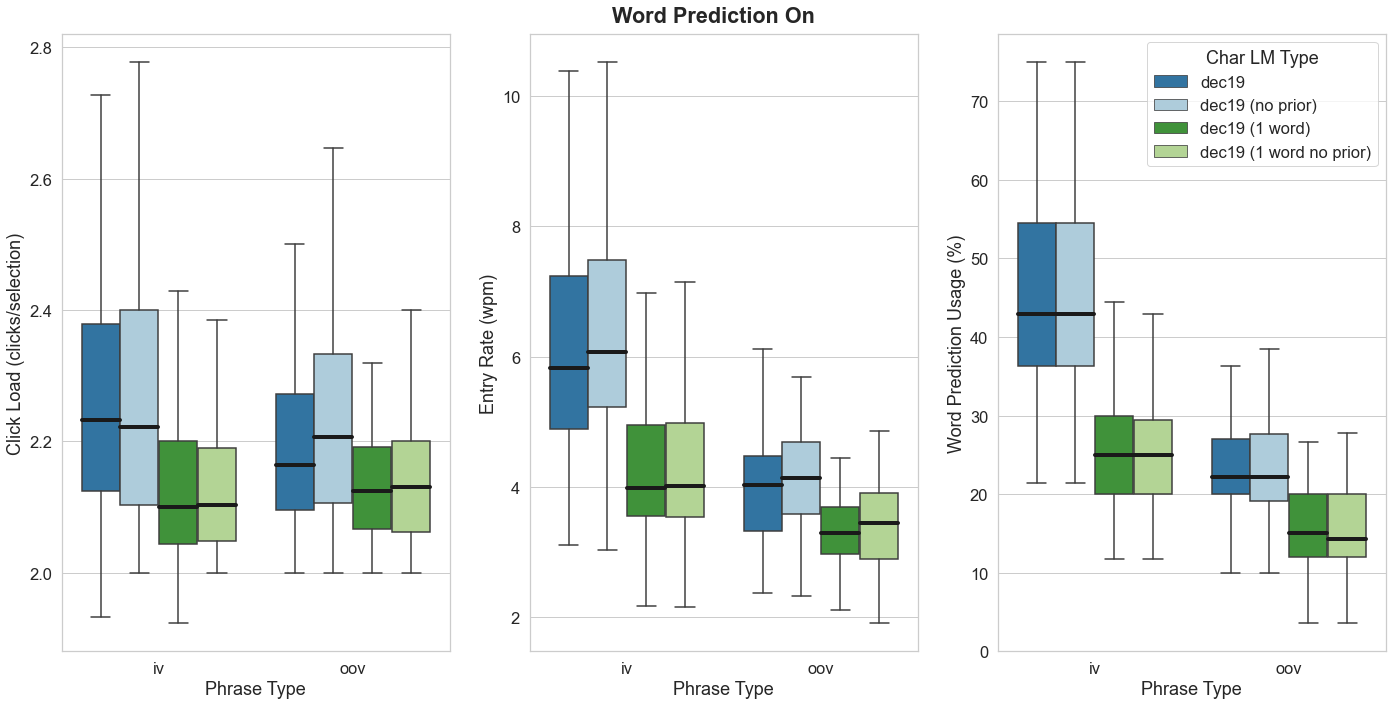

In [171]:
# setup and format a double figure for the plots
fig, axes = plt.subplots(1,3, figsize=(20, 10))
fig.tight_layout(pad=2)
sns.set_context("paper")
sns.set(font_scale=1.5)
sns.set_style("whitegrid")

# # plot the data as boxplots

for row_num, phrase_set in enumerate(["watch"]):
    plot_df = phrase_df.loc[phrase_df["word_lm_type"] != "off"]
    plot_df = plot_df.loc[plot_df["phrase_set"] == phrase_set]
    
    palette = sns.color_palette("Paired", 2)[::-1]+sns.color_palette("Paired", 4)[3::-1]
    hue_order = ["dec19", "dec19 (no prior)", "dec19 (1 word)",  "dec19 (1 word no prior)"]
    
    dep_vars = ["Click Load (clicks/selection)", "Entry Rate (wpm)", "Word Prediction Usage (%)"]

    for col_num, dep_var in enumerate(dep_vars):
        cur_ax = axes[ col_num]
        
        box = sns.boxplot(data=plot_df, x="Phrase Type", y=dep_var, order=["iv", "oov"],
                    hue="word_lm_type", hue_order=hue_order, palette=palette,
                    showfliers=False, medianprops={"color": "k", "linewidth": 4}, ax=cur_ax)
        
        if dep_var == "Correction Rate (%)":
            cur_ymax = cur_ax.get_ylim()[1]
            cur_ax.set_ylim(0, max(10, cur_ymax))
            
        if col_num != 2:
            cur_ax.get_legend().remove()
        else:
            cur_ax.legend(loc=1)
            cur_ax.get_legend().set_title("Char LM Type")


# fig.text(-0.02, 0.25, 'LM Likely Phrase Set', ha='center', va='center', rotation='vertical', fontsize="large", fontweight="bold")
# fig.text(-0.02, 0.75, 'Watch Phrase Set', ha='center', va='center', rotation='vertical', fontsize="large", fontweight="bold")


fig.suptitle("Word Prediction On", fontsize="large", fontweight="bold")


Text(0.5, 0.98, 'Word Prediction On')

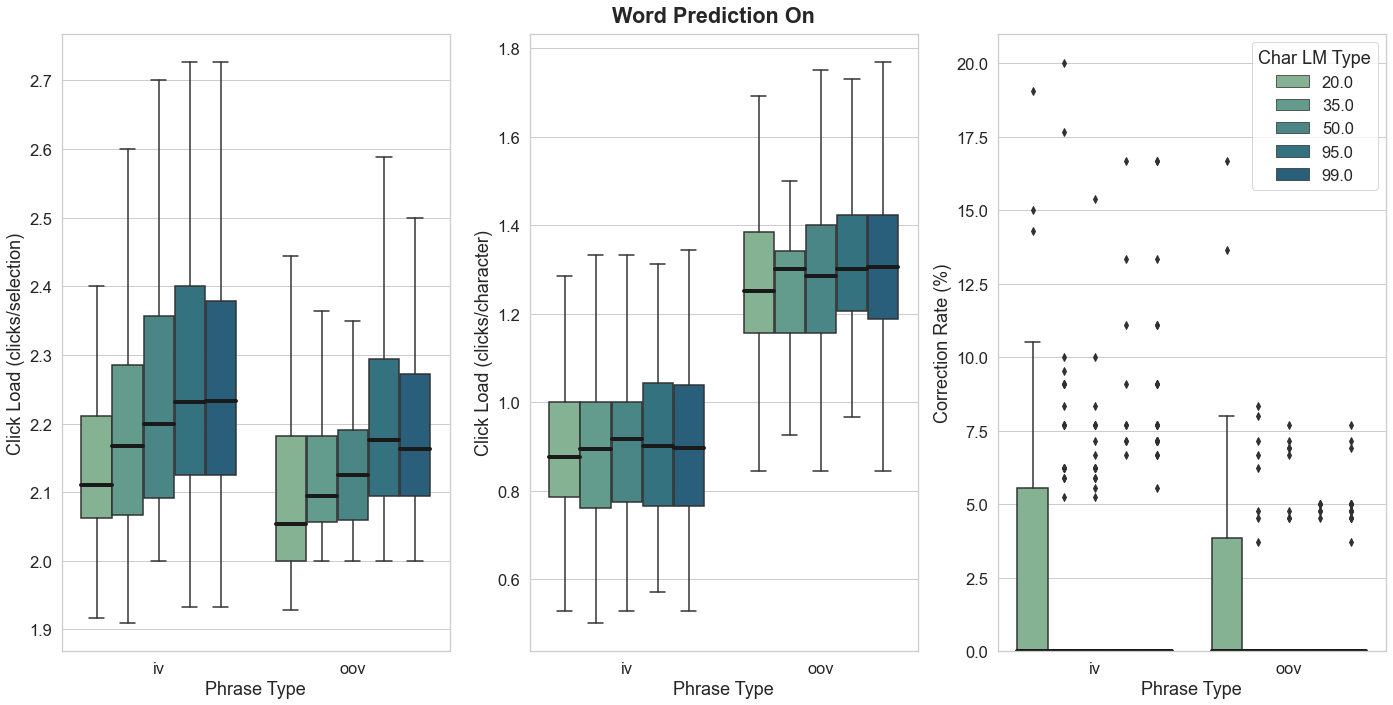

In [232]:
# setup and format a double figure for the plots
fig, axes = plt.subplots(1,3, figsize=(20, 10))
fig.tight_layout(pad=2)
sns.set_context("paper")
sns.set(font_scale=1.5)
sns.set_style("whitegrid")

# # plot the data as boxplots

for row_num, phrase_set in enumerate(["watch"]):
    plot_df = phrase_df.loc[phrase_df["word_lm_type"] == "dec19"]
    plot_df = plot_df.loc[plot_df["phrase_set"] == phrase_set]
    
    palette = sns.color_palette("Paired", 2)[::-1]+sns.color_palette("Paired", 4)[3::-1]
    
    dep_vars = ["Click Load (clicks/selection)", "Click Load (clicks/character)", "Correction Rate (%)"]

    for col_num, dep_var in enumerate(dep_vars):
        cur_ax = axes[ col_num]
        palette = sns.color_palette("crest")
        box = sns.boxplot(data=plot_df, x="Phrase Type", y=dep_var, order=["iv", "oov"],
                    hue="win_diff", palette=palette,
                    showfliers=dep_var == "Correction Rate (%)", medianprops={"color": "k", "linewidth": 4}, ax=cur_ax)
        
        if dep_var == "Correction Rate (%)":
            cur_ymax = cur_ax.get_ylim()[1]
            cur_ax.set_ylim(0, max(10, cur_ymax))
            
        if col_num != 2:
            cur_ax.get_legend().remove()
        else:
            cur_ax.legend(loc=1)
            cur_ax.get_legend().set_title("Char LM Type")


# fig.text(-0.02, 0.25, 'LM Likely Phrase Set', ha='center', va='center', rotation='vertical', fontsize="large", fontweight="bold")
# fig.text(-0.02, 0.75, 'Watch Phrase Set', ha='center', va='center', rotation='vertical', fontsize="large", fontweight="bold")


fig.suptitle("Word Prediction On", fontsize="large", fontweight="bold")


In [213]:
import re

lm_name = "dec19 (20 win diff)"

click_data_folder = "./click_results/"+lm_name
data_fnames = get_csvs_recursive(click_data_folder)

# combine all files into a longform dataframe for plotting
sim_dfs= []
for filename in data_fnames:
    cur_df = pd.read_csv(filename)
    sim_dfs += [cur_df]
        
click_df = pd.concat(sim_dfs).reset_index(drop=True)
click_df["clicks_remaining"] = click_df["num_clicks_selection"] - click_df["click_num"]
click_df["selection_process"] = click_df["phrase_num"]+click_df["selection_num"]/50

click_df = click_df.loc[click_df["num_clicks_selection"] > 1]

one_click_entropys = []
for phrase_num in click_df.phrase_num.unique():
    click_df_phrase = click_df[click_df["phrase_num"] == phrase_num]
    for selection_num in click_df_phrase.selection_num.unique():
        click_df_sel = click_df_phrase[click_df_phrase["selection_num"] == selection_num]
        max_clicks = click_df_sel.click_num.max()
        
        one_click_entropy = click_df_sel[click_df_sel["click_num"] == max_clicks-1].cscore_entropy.values[0]
        one_click_entropys += [one_click_entropy for _ in range(max_clicks+1)]
        
        
click_df["one_click_entropy"] = one_click_entropys

target_clock_probs = []
for row_num, row in click_df.iterrows():
    target_text = row["target_clock_text"]
    
    if target_text in row:
        target_prob = row[target_text]
        
    else:
        row_matches = row[row == target_text]
        word_col_name = [col_name for col_name in row_matches.keys() if re.search('word_.+_text', col_name) is not None][0]
        target_prob = row[word_col_name[:-4]+"cscore"]
    
    target_clock_probs +=[target_prob]
click_df["target_clock_prob"] = target_clock_probs

selected_clock_probs = []
for row_num, row in click_df.iterrows():
    selected_text = row["selected_clock_text"]
    
    if selected_text in row:
        selected_prob = row[selected_text]
        
    else:
        row_matches = row[row == selected_text]
        word_col_name = [col_name for col_name in row_matches.keys() if re.search('word_.+_text', col_name) is not None][0]
        selected_prob = row[word_col_name[:-4]+"cscore"]
    
    selected_clock_probs +=[selected_prob]
click_df["selected_clock_prob"] = selected_clock_probs

click_df

,phrase_num,click_num,selection_num,target_clock_ind,target_clock_text,is_post_undo,num_clocks_on,cscore_entropy,word_0_cscore,word_0_text,...,_,num_clicks_selection,selected_clock_ind,selected_clock_text,is_correct_selection,clicks_remaining,selection_process,one_click_entropy,target_clock_prob,selected_clock_prob
0,1,0,0,55,n,False,49,5.361861e+00,-3.946377,and_,...,-6.135199,3,88,what_,False,3,1.00,1.359514,-3.687162e+00,-3.893617e+00
1,1,1,0,55,n,False,49,2.724233e+00,-23.001725,and_,...,-54.457025,3,88,what_,False,2,1.00,1.359514,-2.586486e+01,-5.290059e+00
2,1,2,0,55,n,False,49,1.359514e+00,-29.268392,and_,...,-52.944958,3,88,what_,False,1,1.00,1.359514,-4.512185e+01,-2.443993e+00
3,1,3,0,55,n,False,49,1.498878e-04,-44.273587,and_,...,-102.585574,3,88,what_,False,0,1.00,1.359514,-5.191389e+01,-8.033012e-06
4,1,0,1,123,UNDO,False,49,5.344311e+00,-3.372770,are_,...,-6.173118,3,123,UNDO,True,3,1.02,0.264413,-3.713572e+00,-3.713572e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5431,122,2,23,111,.,False,49,9.842495e-04,-72.856766,and_,...,-79.134449,2,111,.,True,0,122.46,2.089417,-6.244644e-05,-6.244644e-05
5432,122,0,24,111,.,False,49,5.402084e+00,-4.231712,and_,...,-6.029235,3,111,.,True,3,122.48,1.262194,-6.029235e+00,-6.029235e+00
5433,122,1,24,111,.,False,49,2.170984e+00,-46.063984,and_,...,-45.080308,3,111,.,True,2,122.48,1.262194,-8.711244e+00,-8.711244e+00
5434,122,2,24,111,.,False,49,1.262194e+00,-47.411863,and_,...,-81.091827,3,111,.,True,1,122.48,1.262194,-1.296725e+00,-1.296725e+00


Text(0.5, 0.98, 'dec19 (20 win diff)')

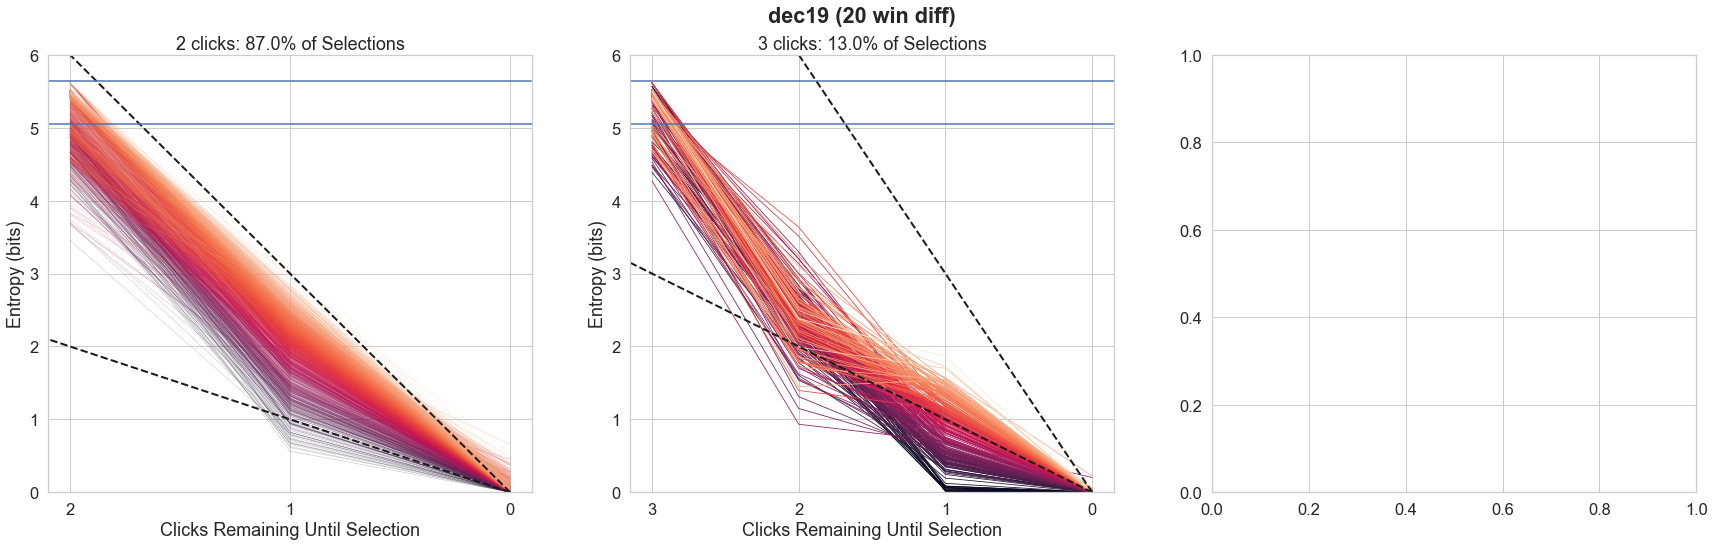

In [185]:
from matplotlib.ticker import MaxNLocator

fig, axes = plt.subplots(1, 3, figsize=(25, 8))
plt.tight_layout(pad=3)
sns.set_context("paper")
sns.set(font_scale=1.5)
sns.set_style("whitegrid")

num_selections_tot = len(click_df["selection_process"].unique())

for ax_ind, num_clicks in enumerate([2, 3]):
    ax = axes[ax_ind]

    plot_df = click_df[click_df["num_clicks_selection"] == num_clicks]
    
    num_lines = len(plot_df["selection_process"].unique())
    ax.set_title(str(num_clicks)+" clicks: "+str(np.round(num_lines/num_selections_tot*100))+"% of Selections")
    
    sns.lineplot(data=plot_df, x="clicks_remaining", y="cscore_entropy", 
                     units="selection_process",  hue="one_click_entropy", palette=sns.color_palette("rocket", as_cmap=True),
                     linewidth=max(min(1800/num_lines*0.1, 1), 0.1),
                     errorbar=None, estimator=None, ax=ax)

    ax.invert_xaxis()
    ax.axline([0, 0], [num_clicks, num_clicks], color="k", linestyle="--", linewidth=2)
    ax.axline([0, 0], [num_clicks, num_clicks*3], color="k", linestyle="--", linewidth=2)
    ax.axhline(np.log2(32+17+1))
    ax.axhline(np.log2(32+1))
    ax.set_ylim(0, 6)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    
    ax.set_ylabel("Entropy (bits)")
    ax.set_xlabel("Clicks Remaining Until Selection")
    ax.get_legend().remove()
    
fig.suptitle(lm_name, fontsize="large", fontweight="bold")

Text(0.5, 0.98, 'dec19 (20 win diff)')

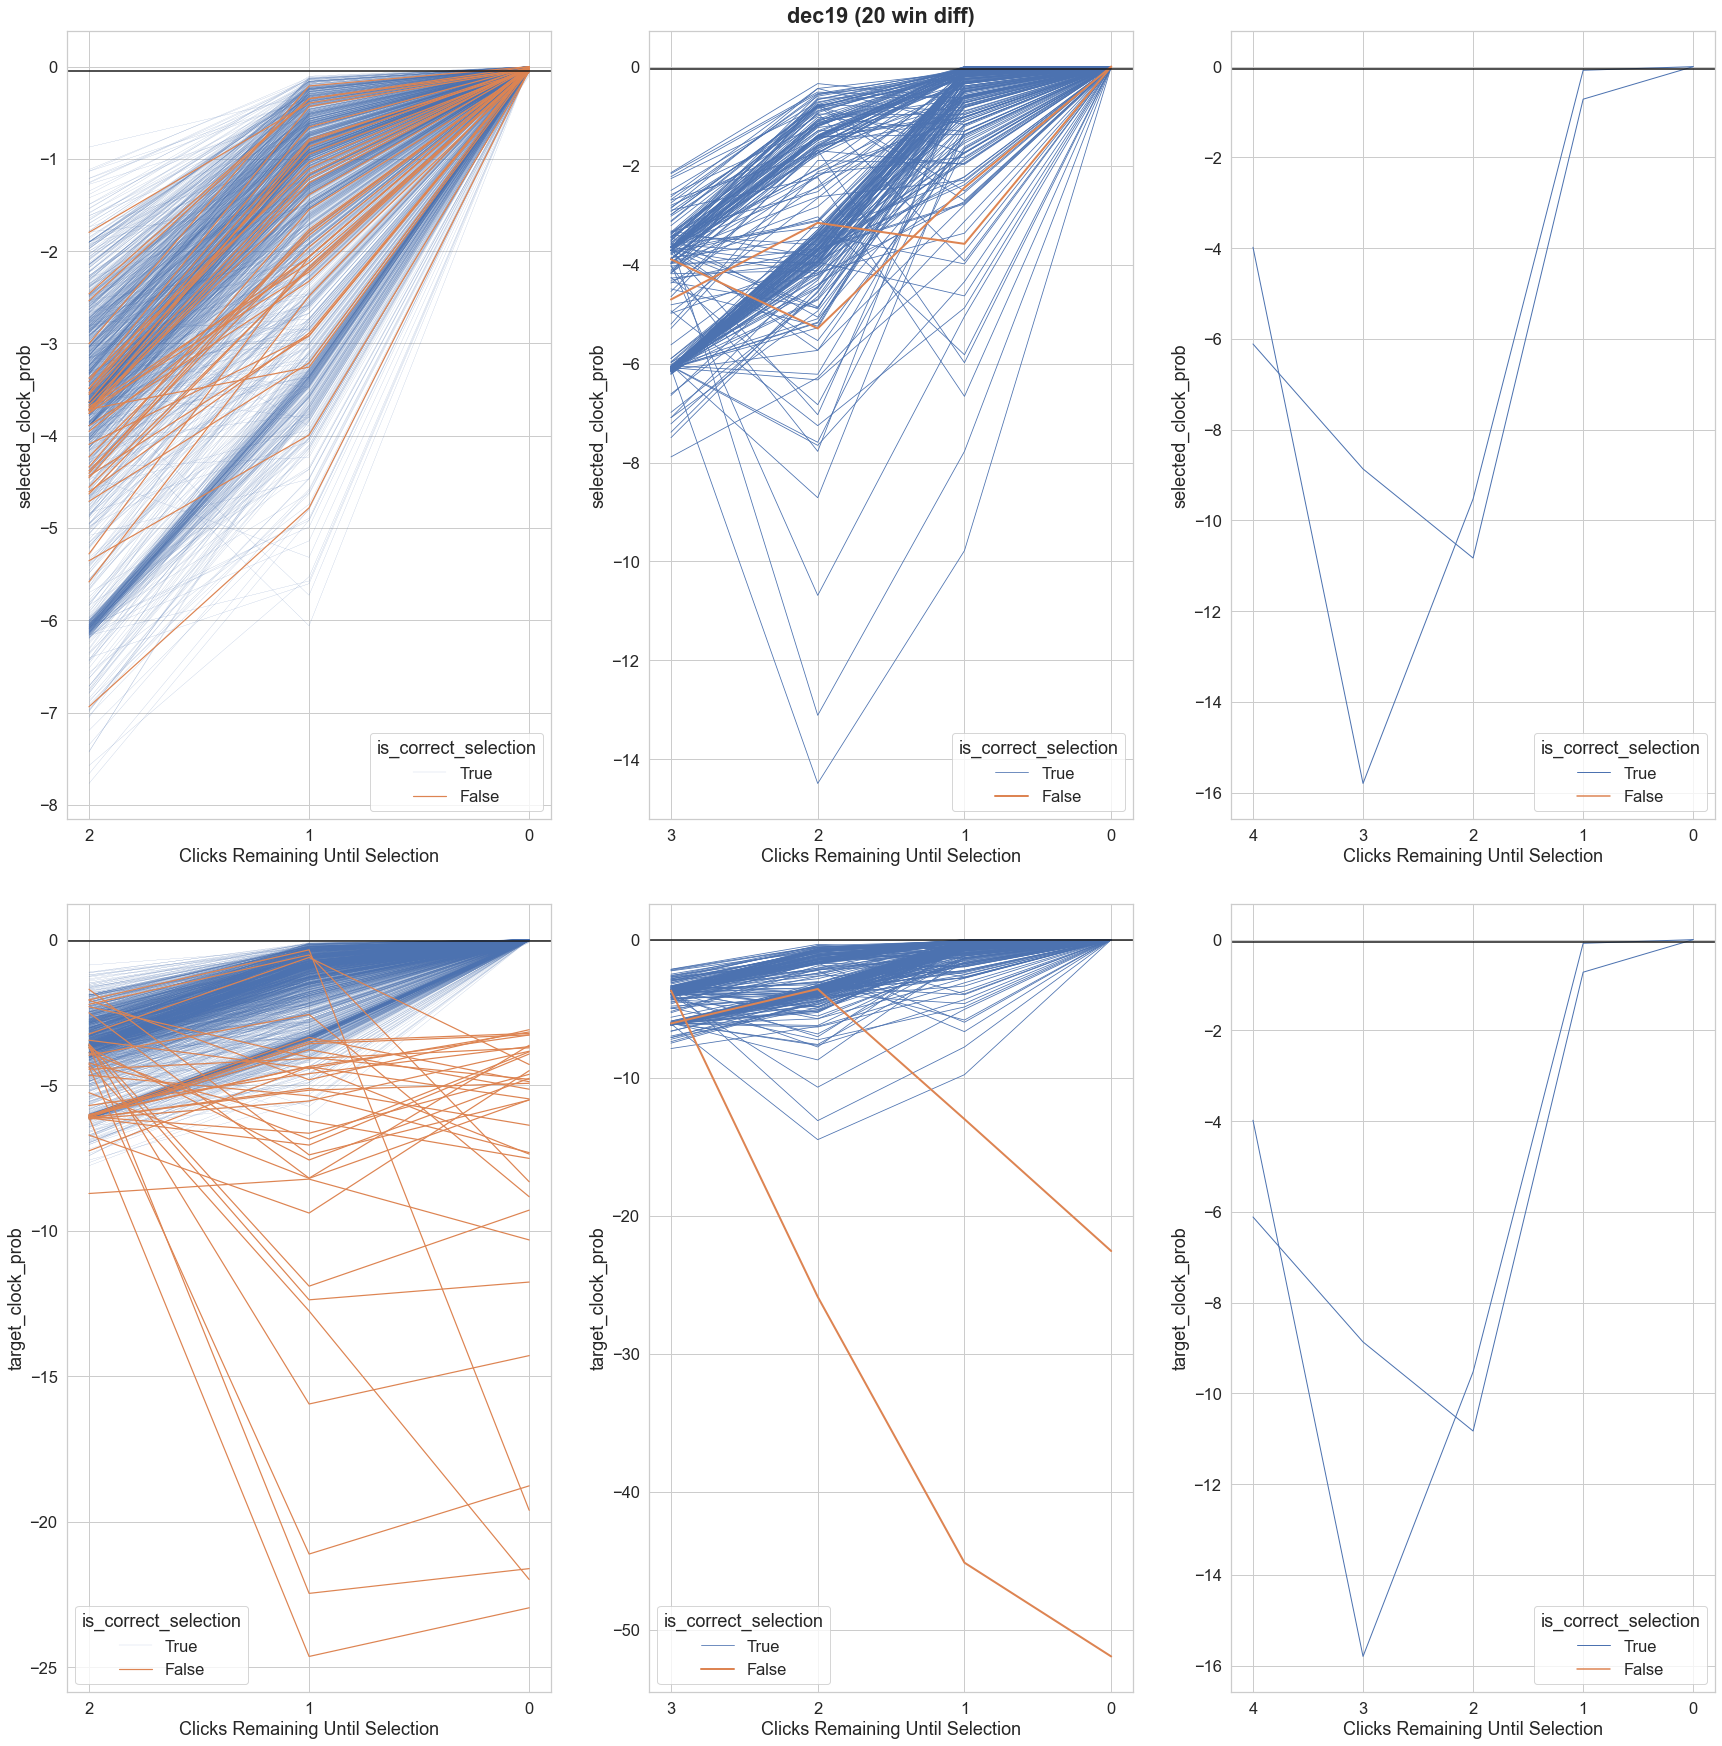

In [214]:
from matplotlib.ticker import MaxNLocator

fig, axes = plt.subplots(2, 3, figsize=(25, 25))
plt.tight_layout(pad=3)
sns.set_context("paper")
sns.set(font_scale=1.5)
sns.set_style("whitegrid")

num_selections_tot = len(click_df["selection_process"].unique())

for col_ind, num_clicks in enumerate([2, 3, 4]):

    plot_df = click_df[click_df["num_clicks_selection"] == num_clicks]
    
    num_lines = len(plot_df["selection_process"].unique())
#     ax.set_title(str(num_clicks)+" clicks: "+str(np.round(num_lines/num_selections_tot*100))+"% of Selections")
#     plot_df = plot_df.loc[plot_df["is_correct_selection"] == False]

    for row_ind, dep_var in enumerate(["selected_clock_prob", "target_clock_prob"]):
        ax = axes[row_ind, col_ind]
    
        sns.lineplot(data=plot_df, x="clicks_remaining", y=dep_var, 
                         units="selection_process",  hue="is_correct_selection", hue_order = [True, False],
                         size="is_correct_selection", sizes = {True: max(min(1800/num_lines*0.1, 1), 0.1), False: max(min(1800/num_lines*1, 2), 1)},
                         errorbar=None, estimator=None, ax=ax)

        ax.invert_xaxis()

    #     ax.set_ylim(np.log(0.5), 0)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.axhline(np.log(0.95), color="k")

    #     ax.set_ylabel("Entropy (bits)")
        ax.set_xlabel("Clicks Remaining Until Selection")
    #     ax.get_legend().remove()
    
fig.suptitle(lm_name, fontsize="large", fontweight="bold")

In [215]:
num_selections = len(click_df["selection_process"].unique())
np.sum(click_df.groupby(by="selection_process").mean()["is_correct_selection"].values)/num_selections*100

97.72859638905067

95.0

<AxesSubplot:xlabel='Click Time Relative (s)', ylabel='Probability'>

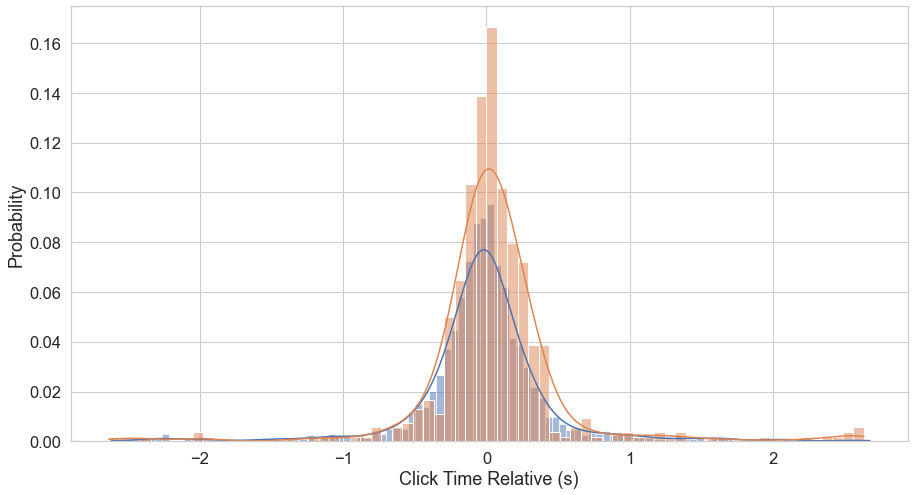

In [243]:
fig, axes = plt.subplots(1, figsize=(15, 8))
sns.set_context("paper")
sns.set(font_scale=1.5)
sns.set_style("whitegrid")

click_data_fname = "../../../Nomon_User_Data/OSF Data/picture_selection_task/user_G_click_data.csv"
click_df =  pd.read_csv(click_data_fname)
click_df = click_df[click_df["Session Num"]>1]
sns.histplot(data=click_df, x="Click Time Relative (s)", kde=True, stat="probability")


click_data_fname = "../../../Nomon_User_Data/OSF Data/text_entry_task/user_G_text_click_data_clean.csv"
click_df =  pd.read_csv(click_data_fname)
sns.histplot(data=click_df, x="Click Time Relative (s)", kde=True, stat="probability")

In [111]:
click_df[click_df["Click Time Relative (s)"] > 0.5]

,Session Num,Phrase Num,Selection Num,Click Num,Task,Phrase Text,Typed Text,Target,Selection,Clock Period (s),Click Time Relative (s),Click Time Absolute (s),Dead Time (s)
159,1,4,1,4,text,conte's blue and white army,c,NaN,c,2.207,0.7151,1651587295,1.340
316,2,4,1,3,text,scam before you get scammed,s,NaN,s,2.207,0.7679,1651675033,1.330
444,3,2,19,1,text,just did an undertale personality quiz,just did an undertale pers,NaN,s,2.207,1.0658,1652363810,4.102
479,3,3,1,2,text,he just can't move on,h,NaN,h,2.207,0.9914,1652363890,2.121
480,3,3,1,3,text,he just can't move on,h,NaN,h,2.207,0.5678,1652363891,1.140
512,3,4,1,1,text,bring back the gold girls,b,NaN,b,2.207,0.5658,1652363961,2.711
514,3,4,1,3,text,bring back the gold girls,b,NaN,b,2.207,0.6357,1652363963,1.151
556,3,4,12,4,text,bring back the gold girls,bring back the gold girls.._,NaN,.,2.207,0.6357,1652364055,1.141
557,3,5,1,1,text,finally a drama for eunjung,f,NaN,f,2.207,0.8657,1652364059,3.751
560,3,5,2,1,text,finally a drama for eunjung,finally_,NaN,finally_,2.207,0.6647,1652364063,1.310
